## Classifying Public-Transport Scenes with **vehicle_image.tflite**

This guide shows how to use the **`vehicle_image.tflite`** model to recognize scenes from different modes of public transport.

---

### 1. Background  

- **Training details**  
  The complete training workflow is documented in `notebooks/train_image_classifier.ipynb`.  
  For an in-depth walkthrough, see the official tutorial:  
  <https://www.tensorflow.org/tutorials/images/transfer_learning?hl=fr>

---

### 2. required Assets available in the repo under models/assets

| Purpose | File / Folder |
|---------|------------------------------|
| Pre-trained model | `models/assets/vehicle_image.tflite` |
| Test images (9 sample) | `models/assets/image_dataset_folder_test/` |

> *You can, of course use here your own images instead of this*

---

### 3. Preparation  

1. Download the model and the sample image folder  
2. In your script, update the paths

> Once the paths are set, a single script run will output the predictions for all nine images.


Found 9 files belonging to 5 classes.
Test-Klassen: ['bus', 'subway', 'subway (old)', 'train', 'tram']
Erwartete Eingabeform: [  1 160 160   3]
Vorhergesagte Klassen (Indices): [0 1 1 2 2 3 3 4 4]
Tatsächliche Labels (Indices): [0 1 1 2 2 3 3 4 4]
Test Accuracy: 1.0


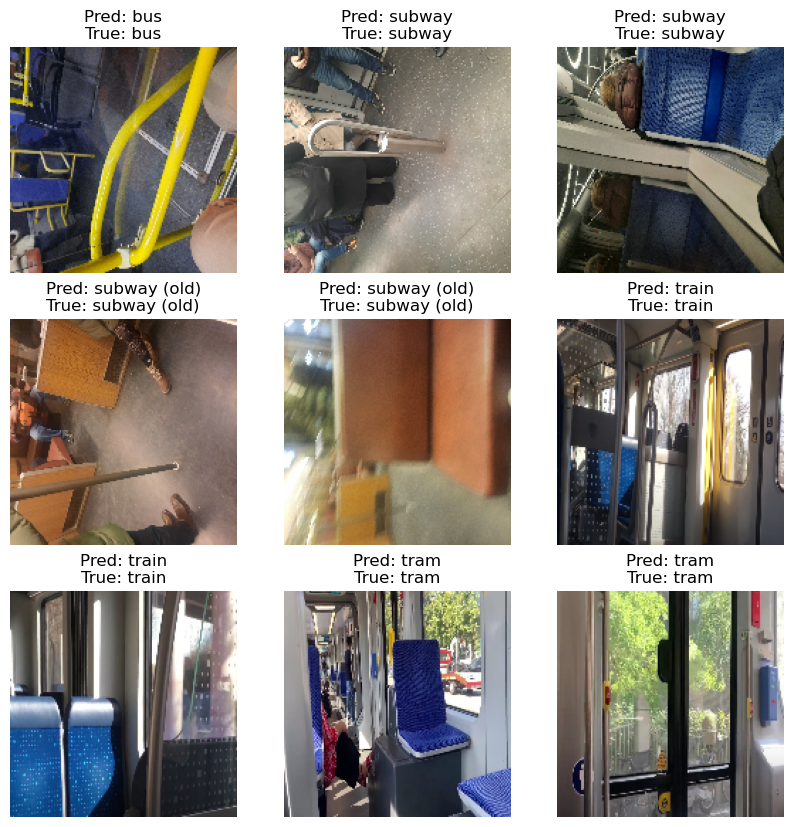

In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# Pfade und Parameter
TFLITE_MODEL_PATH = r"C:\Users\lpera\OneDrive\Desktop\AirquixAppThesis\models\assets\vehicle_image.tflite"
TEST_DATASET_PATH = r"C:\Users\lpera\OneDrive\Desktop\AirquixAppThesis\models\assets\image_dataset_folder_test" # Testordner mit Unterordnern "bus", "subway", "train", "tram"
#TEST_DATASET_PATH = r"C:\Users\lpera\Desktop\Uni\AndroidStudioProjects\Airquix01\app\src\main\assets\old_model.tflite"  # Testordner mit Unterordnern "bus", "subway", "train", "tram"

BATCH_SIZE = 1   # Wir setzen Batchgröße 1, da das TFLite-Modell in der Regel Eingaben mit Batch=1 erwartet
IMG_SIZE = (160, 160)

# 1. Test-Datensatz laden
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DATASET_PATH,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # Für konsistente Reihenfolge
)
# Die automatisch gelesenen Klassen-Namen (Ordnernamen) aus dem Testset
class_names = test_ds.class_names
print("Test-Klassen:", class_names)

# 2. TFLite-Interpreter initialisieren und Modell laden
interpreter = tf.lite.Interpreter(model_path=TFLITE_MODEL_PATH)
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Überprüfe die erwartete Eingabeform (sollte [1, 160, 160, 3] sein)
expected_input_shape = input_details[0]['shape']
print("Erwartete Eingabeform:", expected_input_shape)

# 3. Inferenz über den Test-Datensatz durchführen
all_predictions = []
all_labels = []

for images, labels in test_ds:
    # images hat Shape: (1, 160, 160, 3) (da Batchgröße 1)
    images_np = images.numpy()
    # Setze das Bild in den Interpreter
    interpreter.set_tensor(input_details[0]['index'], images_np)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])  # preds hat Shape (1, num_classes)
    pred_class = np.argmax(preds[0])
    all_predictions.append(pred_class)
    all_labels.append(labels.numpy()[0])

all_predictions = np.array(all_predictions)
all_labels = np.array(all_labels)

print("Vorhergesagte Klassen (Indices):", all_predictions)
print("Tatsächliche Labels (Indices):", all_labels)

# Berechne die Testgenauigkeit
accuracy = np.sum(all_predictions == all_labels) / len(all_predictions)
print("Test Accuracy:", accuracy)

# 4. Visualisierung einiger Testbilder mit Vorhersagen
plt.figure(figsize=(10,10))
# Wir visualisieren die ersten 9 Bilder aus dem Testset
i = 0
for images, labels in test_ds.take(9):
    images_np = images.numpy()
    interpreter.set_tensor(input_details[0]['index'], images_np)
    interpreter.invoke()
    preds = interpreter.get_tensor(output_details[0]['index'])
    pred_class = np.argmax(preds[0])
    true_class = labels.numpy()[0]
    
    ax = plt.subplot(3, 3, i+1)
    plt.imshow(images_np[0].astype("uint8"))
    plt.title(f"Pred: {class_names[pred_class]}\nTrue: {class_names[true_class]}")
    plt.axis("off")
    i += 1
plt.show()
